<a href="https://colab.research.google.com/github/BenzidaneMo/Diabetes-Prediction-using-Machine-Learning/blob/main/Detecting_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [230]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#Load and review

In [231]:
df = pd.read_csv('pima-data.csv')

In [232]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0,33.6,0.627,50,1.3790,True
1,1,85,66,29,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,0,23.3,0.672,32,0.0000,True
3,1,89,66,23,94,28.1,0.167,21,0.9062,False
4,0,137,40,35,168,43.1,2.288,33,1.3790,True


In [233]:
df.isnull().sum()

,0
num_preg,0
glucose_conc,0
diastolic_bp,0
thickness,0
insulin,0
bmi,0
diab_pred,0
age,0
skin,0
diabetes,0


In [234]:
def plot_correlation_matrix(df, figsize=(10, 8)):
    # Select only numerical columns
    numeric_df = df.select_dtypes(include=np.number)

    # Calculate correlation matrix
    correlation = numeric_df.corr()

    # Create heatmap
    plt.figure(figsize=figsize)
    plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

    # Add color bar
    plt.colorbar(label="Correlation")

    # Labels
    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    # Display correlation values
    for i in range(len(correlation.columns)):
        for j in range(len(correlation.columns)):
            plt.text(
                j, i,
                f"{correlation.iloc[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    return correlation

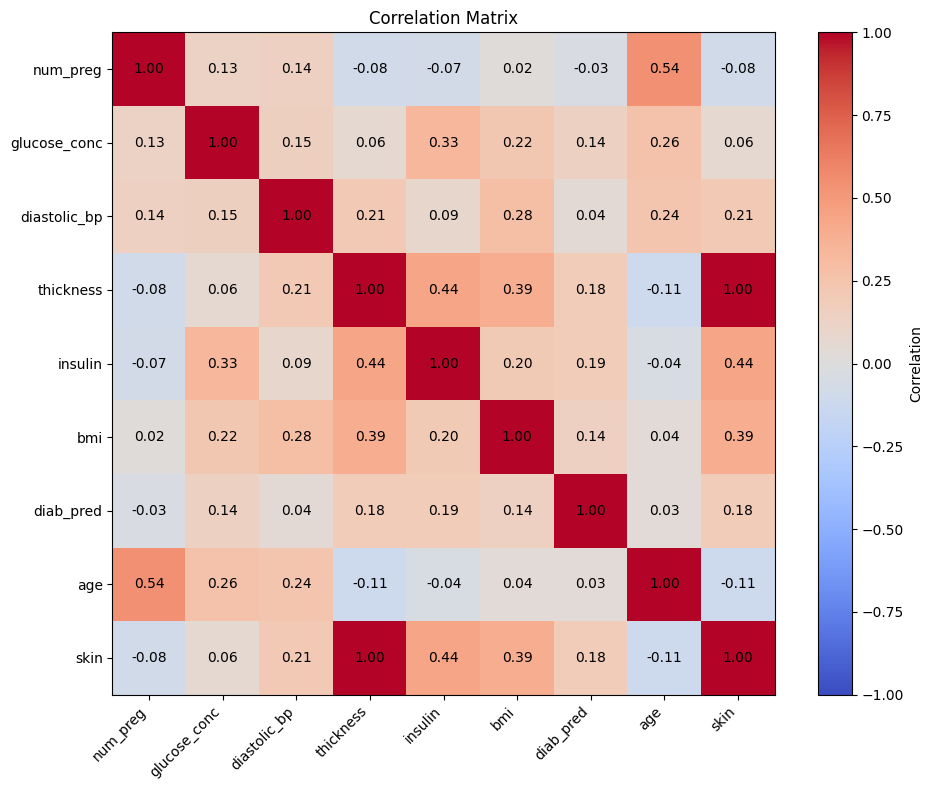

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,-0.081672
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.057328
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.207371
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.436783
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.392573
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.183928
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,-0.113970
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000


In [235]:
plot_correlation_matrix(df)

In [236]:
df.drop('skin', axis=1, inplace=True)

In [237]:
df.rename(columns={"thickness": "skin_thickness"}, inplace=True)

In [238]:
df['diabetes'] = df['diabetes'].map({True: 1, False: 0})

In [239]:
df.head()

,num_preg,glucose_conc,diastolic_bp,skin_thickness,insulin,bmi,diab_pred,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [240]:
percentage = df['diabetes'].value_counts(normalize=True) * 100

print(f"Without disease: {percentage.get(0, 0):.2f}%")
print(f"With disease:    {percentage.get(1, 0):.2f}%")

Without disease: 65.10%
With disease:    34.90%


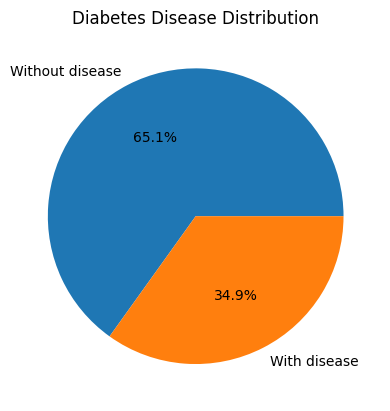

In [241]:
df['diabetes'].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Without disease", "With disease"]
)

plt.ylabel("")
plt.title("Diabetes Disease Distribution")
plt.show()

# Training and Testing

In [242]:
from sklearn.model_selection import train_test_split
# Features
X = df.drop(columns=['diabetes'])

# Target
y = df['diabetes']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [243]:
print("Total:", len(df))
print("Training:", len(X_train))
print("Testing:", len(X_test))

Total: 768
Training: 614
Testing: 154


In [244]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
diabetes
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Testing distribution:
diabetes
0    64.935065
1    35.064935
Name: proportion, dtype: float64


## Scaling the features

In [245]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Algorithms

In [246]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1500)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [247]:
# SVM
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [248]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [249]:
# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [250]:
# Compile and train
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Early stopping allows the model to stop when validation performance stops improving.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6538 - loss: 0.6595 - val_accuracy: 0.6423 - val_loss: 0.6199
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6660 - loss: 0.5840 - val_accuracy: 0.7480 - val_loss: 0.5197
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7352 - loss: 0.5215 - val_accuracy: 0.8049 - val_loss: 0.4812
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7597 - loss: 0.5017 - val_accuracy: 0.7967 - val_loss: 0.4561
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7719 - loss: 0.4676 - val_accuracy: 0.7805 - val_loss: 0.4462
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7719 - loss: 0.4680 - val_accuracy: 0.8049 - val_loss: 0.4450
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4566 - val_accuracy: 0.8049 - val_loss: 0.4254
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7739 - loss: 0.4538 - val_accuracy: 0.7967 - v

# Evaluation

In [251]:
# Evaluate
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

In [252]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

#y_probability = model.predict(X_test_scaled)
#y_pred_ann = (y_probability >= 0.4).astype(int).ravel()

# ANN probabilities
y_probability_ann = model.predict(X_test_scaled).ravel()

# ANN prediction
y_pred_ann = (y_probability_ann >= 0.4).astype(int)

# SVM probabilities
y_probability_svm = svm.predict_proba(X_test_scaled)[:, 1]

# ANN + SVM Ensemble
ensemble_probability = (
    y_probability_ann + y_probability_svm
) / 2

# Final prediction
y_pred_ensemble = (
    ensemble_probability >= 0.4
).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


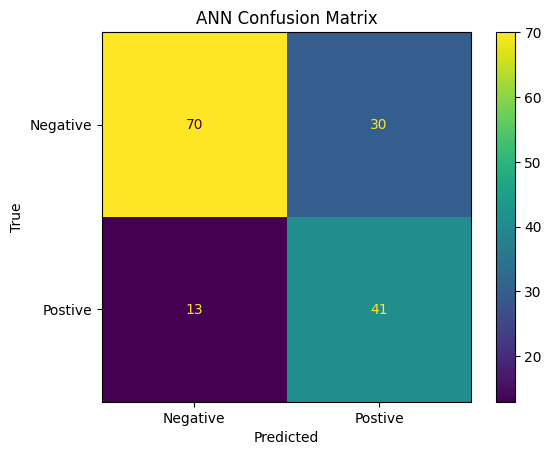

In [253]:
# 10. Confusion matrix
cm = confusion_matrix(y_test, y_pred_ann)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Postive"]
)

disp.plot()
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("ANN Confusion Matrix")
plt.show()

## Models Comparison

In [254]:
print("ANN")
print(classification_report(y_test, y_pred_ann))

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("ANN + SVM Ensemble")
print(classification_report(y_test, y_pred_ensemble))

ANN
              precision    recall  f1-score   support

           0       0.84      0.70      0.77       100
           1       0.58      0.76      0.66        54

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154

Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

SVM
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75   

In [255]:
# Store predictions
predictions = {
    "ANN": y_pred_ann,
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "ANN + SVM": y_pred_ensemble
}

# Extract metrics
results = {}

for model_name, y_pred in predictions.items():
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    results[model_name] = {
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"]
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T

print(results_df)

                     Accuracy  Precision    Recall  F1-Score
ANN                  0.720779   0.577465  0.759259  0.656000
Logistic Regression  0.714286   0.608696  0.518519  0.560000
SVM                  0.753247   0.660000  0.611111  0.634615
Random Forest        0.746753   0.653061  0.592593  0.621359
ANN + SVM            0.733766   0.600000  0.722222  0.655462


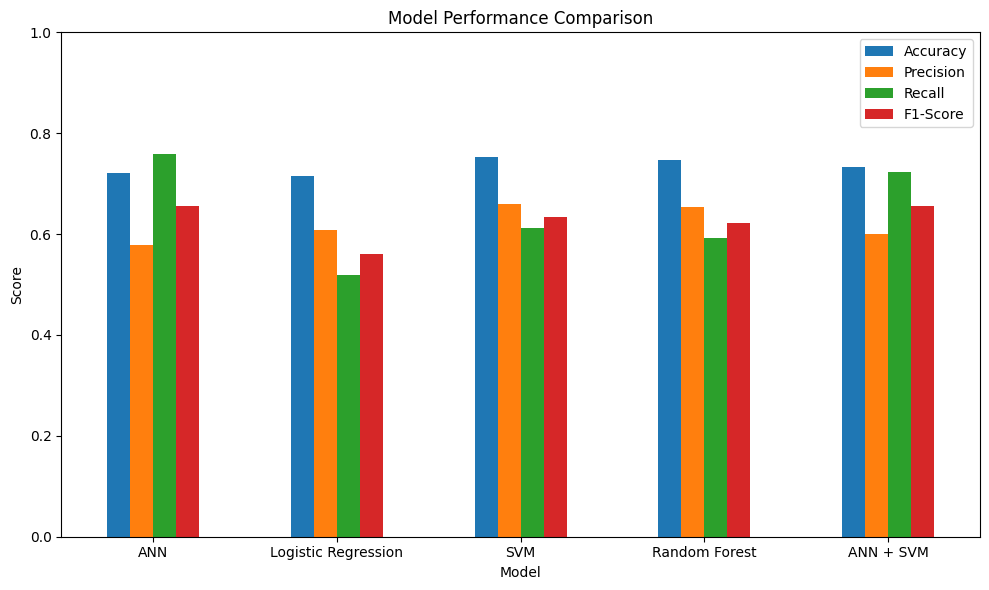

In [256]:
results_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()